# Analyse des AOI

Ce notebook permet de corréler les données de fixation avec les zones d'intérêt (AOI) du stimulus.

Objectifs :

- Charger le stimulus
- Charger les AOI
- Charger les données eye-tracking
- Vérifier visuellement l'alignement
- Associer les fixations aux syllabes

# Configuration

Cette cellule centralise tous les paramètres du notebook.

In [812]:
# ==========================================================
# CONFIGURATION
# ==========================================================

# Stimulus

STIMULUS_PATH = "data/stimuli/s7_stimuli_t1.jpg"

# Eye Tracking

EYE_TRACKING_PATH = "data/eye_tracking/s7_tracking.csv"

# AOI
FIXATION_RADIUS = 69

MIN_FIXATION_POINTS = 55

AOI_PATH = "data/aoi/Syllables_rois.csv"

# Affichage

FIGSIZE = (16, 10)

AOI_COLOR = "red"

AOI_LINEWIDTH = 1

FIXATION_SIZE = 20

FIXATION_ALPHA = 0.1

#couleur du graphique
POINT_COLOR = "#8B5E5E"

ALPHA = 0.55

print("Configuration chargée")

Configuration chargée


# Import des bibliothèques

In [813]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle

import cv2

# Chargement des données

In [814]:
# ==========================================================
# CHARGEMENT DES DONNEES
# ==========================================================

eye_df = pd.read_csv(
    EYE_TRACKING_PATH
)

aoi_df = pd.read_csv(
    AOI_PATH
)

stimulus = cv2.imread(
    STIMULUS_PATH
)

stimulus = cv2.cvtColor(
    stimulus,
    cv2.COLOR_BGR2RGB
)

print(
    f"Nombre de mesures : {len(eye_df)}"
)

print(
    f"Nombre d'AOI : {len(aoi_df)}"
)

Nombre de mesures : 18247
Nombre d'AOI : 100


# Préparation des données eye-tracking

Le projet DyslexIA utilise :

- fix_x
- fix_y

comme référence pour les positions de fixation.

In [815]:
# ==========================================================
# PREPARATION EYE TRACKING
# ==========================================================

eye_df["timestamp"] = eye_df["time"]

eye_df["x"] = (
    eye_df["gaze_x_left"]
    + eye_df["gaze_x_right"]
) / 2

eye_df["y"] = (
    eye_df["gaze_y_left"]
    + eye_df["gaze_y_right"]
) / 2

eye_df = eye_df[
    [
        "timestamp",
        "x",
        "y",
        "stimfile",
        "subject_id"
    ]
].copy()

eye_df.head()

,timestamp,x,y,stimfile,subject_id
0,328491191,153.945,158.745,s7_stimuli_t1.jpg,1003
1,328495189,152.075,158.755,s7_stimuli_t1.jpg,1003
2,328499187,151.550,157.615,s7_stimuli_t1.jpg,1003
3,328503186,152.230,156.430,s7_stimuli_t1.jpg,1003
4,328507184,151.255,155.020,s7_stimuli_t1.jpg,1003


# Calcul des fixations

Les données brutes sont regroupées en fixations.

Une fixation correspond à un ensemble de points proches dans l'espace.

La durée d'une fixation est utilisée pour dimensionner les bulles de visualisation.

In [816]:
if len(current_fix) > 0:

    fixation_df = pd.DataFrame(current_fix)

    fixations.append(
        {
            "x": fixation_df["x"].mean(),
            "y": fixation_df["y"].mean(),
            "duration":
                fixation_df["timestamp"].max()
                -
                fixation_df["timestamp"].min(),
            "n_points":
                len(fixation_df)
        }
    )

fixations_df = pd.DataFrame(
    fixations
)

print(
    f"Fixations détectées : {len(fixations_df)}"
)

fixations_df.head()

Fixations détectées : 209


,x,y,duration,n_points
0,163.213019,168.317264,207973,53
1,337.816989,173.363239,348033,88
2,452.903265,168.119694,387873,98
3,577.729481,160.158052,303996,77
4,470.081364,171.131162,391996,99


In [817]:
# ==========================================================
# DETECTION DES FIXATIONS
# ==========================================================


fixations = []

current_fix = []

for _, row in eye_df.iterrows():

    if len(current_fix) == 0:
        current_fix.append(row)
        continue

    center_x = np.mean(
        [p["x"] for p in current_fix]
    )

    center_y = np.mean(
        [p["y"] for p in current_fix]
    )

    distance = np.sqrt(
        (row["x"] - center_x) ** 2
        +
        (row["y"] - center_y) ** 2
    )

    if distance <= FIXATION_RADIUS:

        current_fix.append(row)

    else:

        fixation_df = pd.DataFrame(current_fix)

        fixations.append(
    {
        "x": fixation_df["x"].mean(),
        "y": fixation_df["y"].mean(),
        "duration":
            fixation_df["timestamp"].max()
            -
            fixation_df["timestamp"].min(),
        "n_points":
            len(fixation_df)
    }
)

        current_fix = [row]

# Finalisation des fixations

In [818]:
# ==========================================================
# FILTRAGE DES FIXATIONS
# ==========================================================



fixations_df = fixations_df[
    fixations_df["n_points"] >= MIN_FIXATION_POINTS
].copy()

print(
    f"Fixations après filtrage : {len(fixations_df)}"
)

Fixations après filtrage : 109


# Préparation de la visualisation

In [819]:
# Taille des bulles

sizes = np.interp(
    fixations_df["duration"],
    (
        fixations_df["duration"].min(),
        fixations_df["duration"].max()
    ),
    (
        50,
        1500
    )
)

# Progression temporelle

colors = np.linspace(
    0,
    1,
    len(fixations_df)
)

# Préparation des AOI

Le fichier contient :

- des lignes
- des syllabes

Nous conservons uniquement les syllabes.

In [820]:
# ==========================================================
# PREPARATION AOI
# ==========================================================

aoi_df = aoi_df[
    aoi_df["kind"] == "sub-line"
].copy()

print(
    f"Nombre de syllabes : {len(aoi_df)}"
)

aoi_df.head()

Nombre de syllabes : 90


,id,stimfile,content,kind,name,x,y,width,height,line,part,column
1,1,s7_stimuli_t1.jpg,ma,sub-line,line 1 part 1,290,141,88,39,1.0,1.0,1.0
2,2,s7_stimuli_t1.jpg,si,sub-line,line 1 part 2,419,141,88,39,1.0,2.0,2.0
3,3,s7_stimuli_t1.jpg,mu,sub-line,line 1 part 3,545,141,88,39,1.0,3.0,3.0
4,4,s7_stimuli_t1.jpg,zu,sub-line,line 1 part 4,672,141,88,39,1.0,4.0,4.0
5,5,s7_stimuli_t1.jpg,da,sub-line,line 1 part 5,796,141,88,39,1.0,5.0,5.0


# Vérification du stimulus

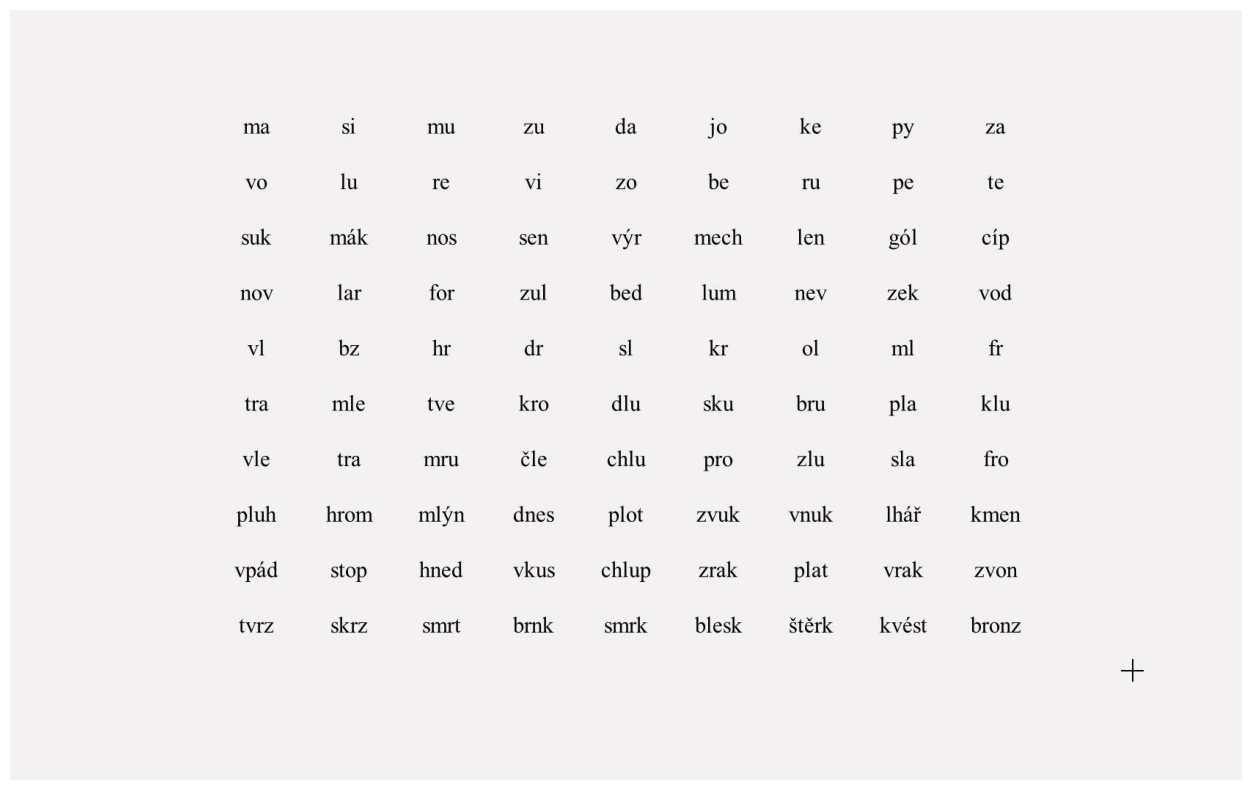

In [821]:
plt.figure(
    figsize=FIGSIZE
)

plt.imshow(
    stimulus
)

plt.axis("off")

plt.show()

# Vérification visuelle des AOI

Affichage des zones d'intérêt sur le stimulus.

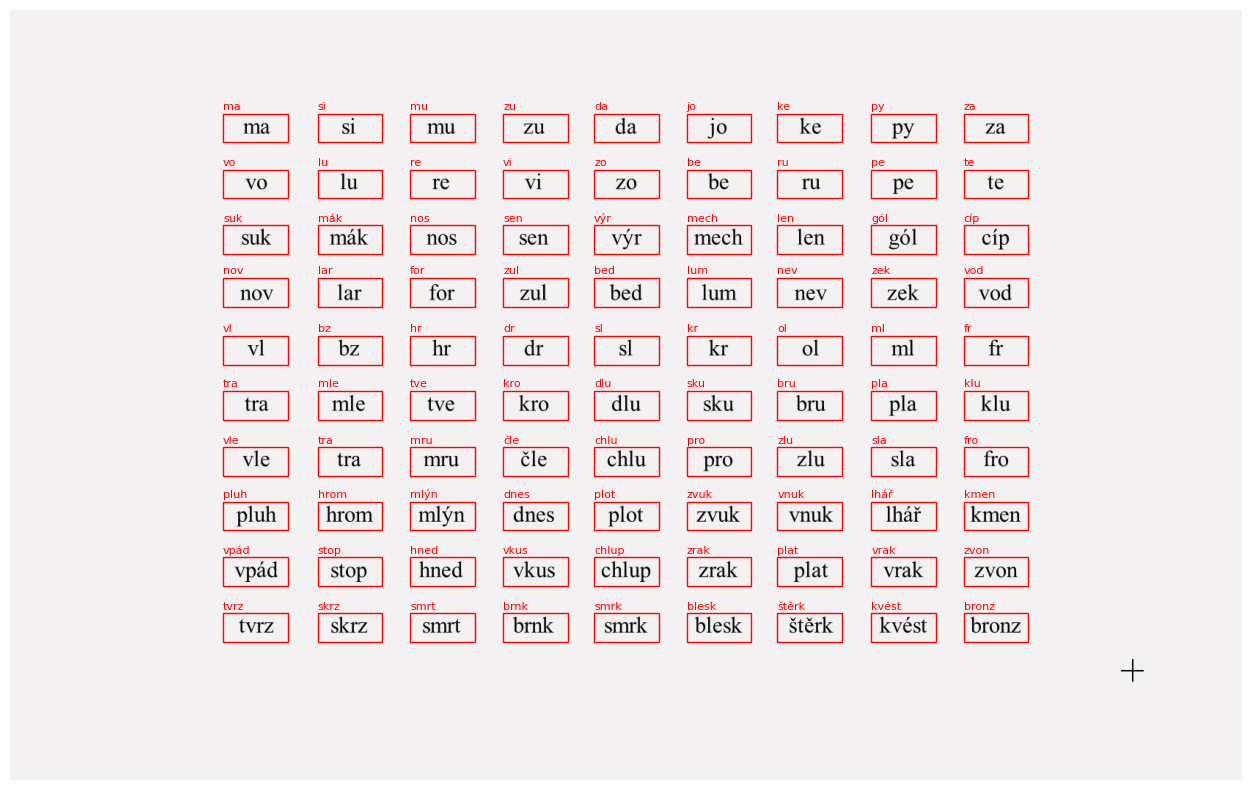

In [822]:
plt.figure(
    figsize=FIGSIZE
)

plt.imshow(
    stimulus
)

ax = plt.gca()

for _, row in aoi_df.iterrows():

    rect = Rectangle(
        (row["x"], row["y"]),
        row["width"],
        row["height"],
        fill=False,
        edgecolor=AOI_COLOR,
        linewidth=AOI_LINEWIDTH
    )

    ax.add_patch(rect)

    plt.text(
        row["x"],
        row["y"] - 5,
        row["content"],
        color=AOI_COLOR,
        fontsize=8
    )

plt.axis("off")

plt.show()

# Vérification AOI + Fixations

Cette visualisation permet de vérifier que les fixations tombent correctement dans les AOI.

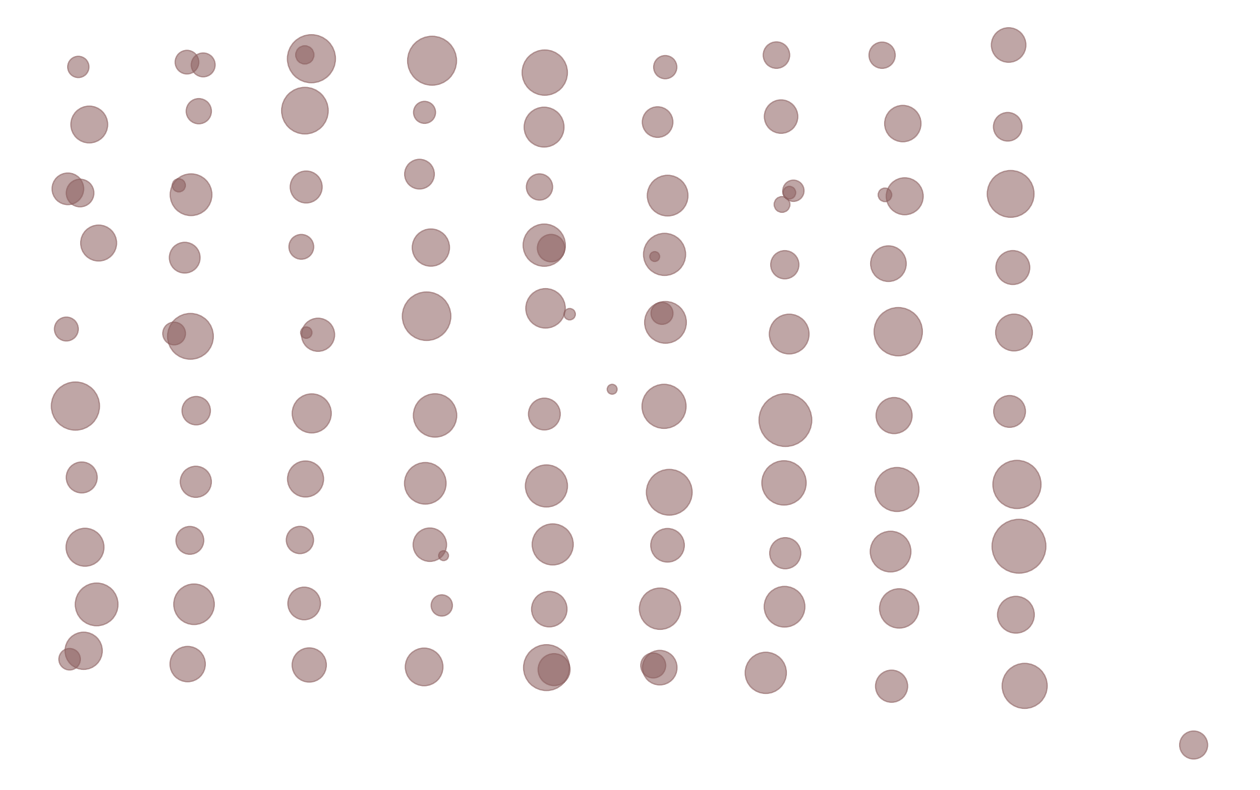

In [823]:
plt.figure(figsize=(16,10))

plt.scatter(
    fixations_df["x"],
    fixations_df["y"],
    s=sizes,
    color=POINT_COLOR,
    alpha=ALPHA
)

plt.gca().invert_yaxis()

plt.axis("off")

plt.show()

# Superposition au stimulus

Affichage des fixations directement sur le texte de lecture.

Taille :
- petite bulle = fixation courte
- grosse bulle = fixation longue

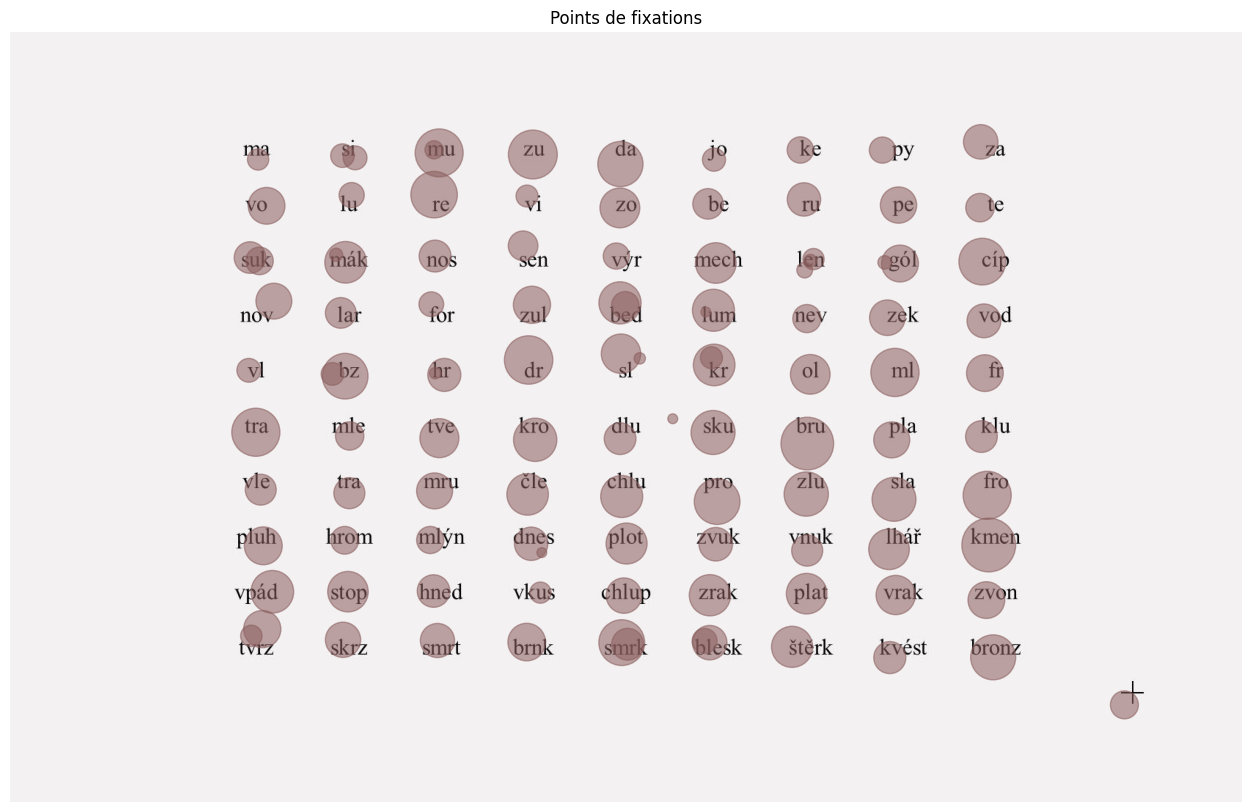

In [824]:
plt.figure(figsize=(16,10))

# Affichage du stimulus
plt.imshow(stimulus)

plt.scatter(
    fixations_df["x"],
    fixations_df["y"],
    s=sizes,
    color=POINT_COLOR,
    alpha=ALPHA
)


plt.title(
    "Points de fixations"
)

plt.axis("off")

plt.show()